--2026-05-08 15:02:32--  https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40697 (40K) [application/x-www-form-urlencoded]
Saving to: ‘parkinsons.data.2’

parkinsons.data.2   100%[===================>]  39.74K   228KB/s    in 0.2s    

2026-05-08 15:02:34 (228 KB/s) - ‘parkinsons.data.2’ saved [40697/40697]

Accuracy: 97.44%
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.97      1.00      0.98        29

    accuracy                           0.97        39
   macro avg       0.98      0.95      0.97        39
weighted avg       0.98      0.97      0.97        39



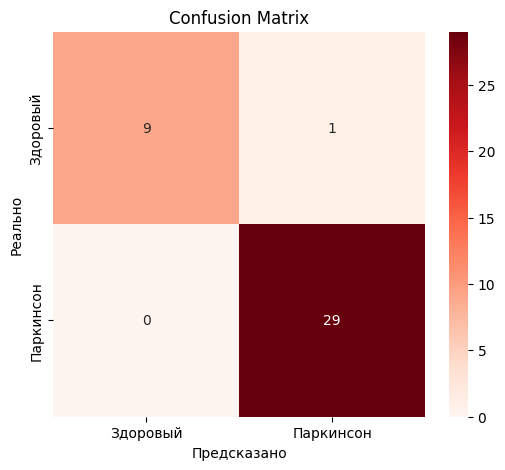

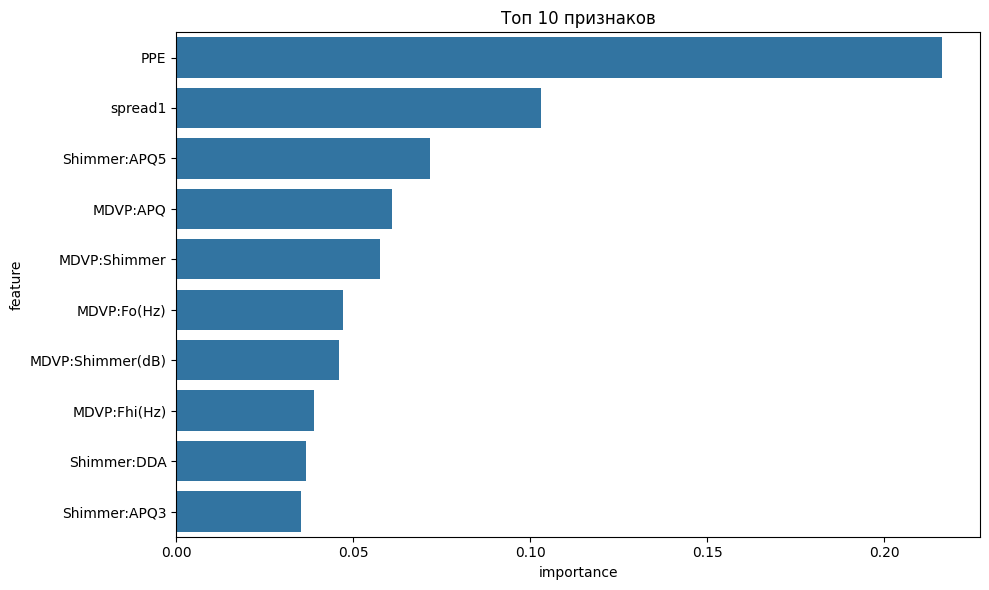

In [3]:
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

!wget "https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data"

data = pd.read_csv('parkinsons.data', sep=',')

x = data.drop(['name', 'status'], axis=1)
y = data['status']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0.1,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=1,
    n_jobs=-1
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(score*100,2)}%')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['Здоровый', 'Паркинсон'],
            yticklabels=['Здоровый', 'Паркинсон'])

plt.xlabel("Предсказано")
plt.ylabel("Реально")
plt.title("Confusion Matrix")
plt.show()

feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Топ 10 признаков')
plt.tight_layout()
plt.show()